# Liora plant project 2 - Preprocessing part

**1. GPU for Colab**

Change the settings to exploit GPU. How: Edit > Notebook settings > select GPU

In [ ]:
# check if GPU is enabled
import tensorflow as tf
if tf.test.gpu_device_name():
    print('Default GPU Device:{}'.format(tf.test.gpu_device_name()))
else:
    print("Please change your hardware accelerator")

Please change your hardware accelerator


 **2. Download data and load packages**

In [ ]:
### Load the data sets
# note: this dataset contains images of plants both with and without disease
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset


In [ ]:
# load basic packages
# linear algebra and data
import numpy as np
import pandas as pd
# plots
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# paths and small utilities
from pathlib import Path
import collections

In [ ]:
# tensorflow
import tensorflow as tf
# sklearn: used for the stratified, file-level train/val/test split
from sklearn.model_selection import train_test_split

In [ ]:
# keras layers used for the augmentation and normalization layers
from tensorflow import keras
from tensorflow.keras import layers

**3. Creating data set with tensorflow**

In [ ]:
# Path to the colour images (we use the 'color' rendering, per the Step 1 report)
SOURCE_DIR = Path(path) / "plantvillage dataset" / "color"

In [ ]:
# --- Split ratios and loading parameters (fixed seed for reproducibility) ---
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Image size.
# NOTE: the Step 1 report concluded "do not resize" because every image is already
# a uniform 256x256x3 square. We deliberately downsample to 128x128 to cut memory
# and speed up training. This is a conscious deviation: it reduces the fine, LOCAL
# detail (spots/lesions) that Step 1 identified as the disease signal, so it should
# be revisited in Step 3 by comparing 128 vs 256 on validation macro-F1.
img_height = 128
img_width  = 128

# Batch size. 32 is a reasonable default for ~54k images on a GPU
# (a very small batch like 8 means more steps/epoch and lower GPU utilisation).
batch_size = 32
seed = 123

# Valid image extensions (used when enumerating files for the split)
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff"}

In [ ]:
# Adrian's loader: tf.keras.utils.image_dataset_from_directory.
# We use it here to confirm the 38 classes and get the canonical (sorted) class
# ordering / file count. The actual train/val/test split is built at FILE LEVEL
# below so it can be stratified and leak-free (this loader's own split is neither).
dataset = tf.keras.utils.image_dataset_from_directory(
    SOURCE_DIR,               # path to colour images
    labels="inferred",        # labels from the directory structure
    image_size=(img_height, img_width),
    batch_size=batch_size,
    seed=seed,
)

Found 54305 files belonging to 38 classes.


In [ ]:
class_names = dataset.class_names
num_classes = len(class_names)
print(num_classes)
### 38 classes (full dataset, before the split)

38


## File-level stratified split (train / val / test)

We collect every image path and its label, then split with `train_test_split(..., stratify=labels)` so each of the 38 classes keeps its proportion in every split. Because the split is built on the file lists (not on a shuffled batch stream), the three sets are **disjoint by construction** - no image can leak across them.

In [ ]:
# --- Build the file-level, stratified split ---
# Enumerate every image path and its integer label directly from the class folders.
# (Done with pathlib so it does not depend on any loader internals; the stray-file
# filter matches what image_dataset_from_directory counts.)
class_to_idx = {name: i for i, name in enumerate(class_names)}
all_paths, all_labels = [], []
for name in class_names:
    for f in sorted((SOURCE_DIR / name).iterdir()):
        if f.is_file() and f.suffix.lower() in IMG_EXTS:
            all_paths.append(str(f))
            all_labels.append(class_to_idx[name])
all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
assert len(np.unique(all_labels)) == num_classes
print(f"Enumerated {len(all_paths)} images across {num_classes} classes")

# 1) carve off the TEST set (stratified)
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=TEST_RATIO,
    stratify=all_labels,
    random_state=seed,
)

# 2) carve the VALIDATION set out of the remainder (stratified)
val_relative = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)   # 0.15 / 0.85
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels,
    test_size=val_relative,
    stratify=train_labels,
    random_state=seed,
)

Enumerated 54305 images across 38 classes


In [ ]:
# --- Turn each split's file list into a tf.data pipeline ---
# Images are decoded, resized to (img_height, img_width) and kept as float32 in the
# [0, 255] range (same as image_dataset_from_directory). Normalization is NOT applied
# here: it is a model layer (see the Normalizing section below).
AUTOTUNE = tf.data.AUTOTUNE

def load_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [img_height, img_width])   # float32, [0,255]
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        # full per-epoch shuffle of the training files
        ds = ds.shuffle(len(paths), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False)

In [ ]:
# --- Verify the split: sizes, all 38 classes present, and no leakage ---
for name, y in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    n_present = len(collections.Counter(y.tolist()))
    print(f"{name:5s}: {len(y):6d} images | classes present: {n_present}/{num_classes}")

# disjoint check (leak-free)
assert set(train_paths).isdisjoint(val_paths)
assert set(train_paths).isdisjoint(test_paths)
assert set(val_paths).isdisjoint(test_paths)
print("OK - splits are disjoint (no image leaks across train/val/test).")

train:  38013 images | classes present: 38/38
val  :   8146 images | classes present: 38/38
test :   8146 images | classes present: 38/38
OK - splits are disjoint (no image leaks across train/val/test).


**4. Defining augementation**

Note that we define the augmentation here but include it as an input while defining the model later.

In [ ]:
##### augmentation layer (applied inside the model, at training time only)
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                   img_width,
                                   3)),   # horizontal flip
    layers.RandomRotation(0.1),          # rotation
    layers.RandomZoom(0.1),              # zoom
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


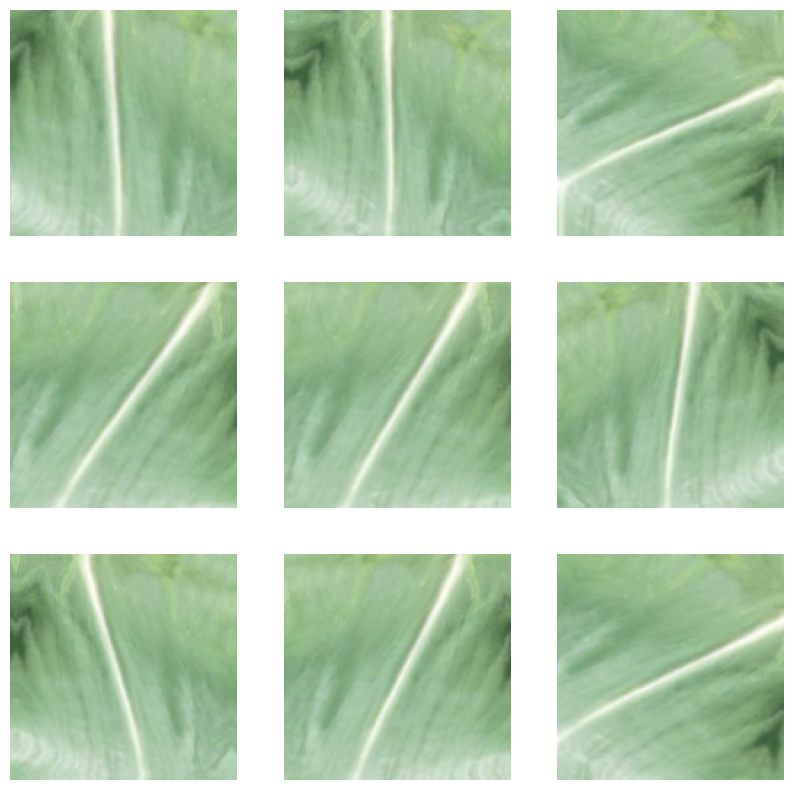

In [ ]:
#### visualize a few augmented img
##### ONLY FOR TRAINING SET
# Our datasets are raw float32 in [0,255] (normalization happens in the model),
# so casting to uint8 for display works fine here.
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

### Note: the earlier "black images" issue only happened when images were normalized
### to [0,1] and then cast to uint8 (which floors everything to 0). Keeping
### normalization in the model (below) avoids that - no need to reorder augmentation.

**5. Normalizing**

In [ ]:
#### Normalization as a layer: included as the FIRST layer of the model later, so
#### train/val/inference all use identical scaling and the datasets themselves can
#### stay raw. Pixel values are 0..255, so divide by 255 (max maps to exactly 1.0).
normalization_layer = layers.Rescaling(1./255)

In [ ]:
### use buffered prefetching
# train_ds already shuffles its files each epoch (see make_dataset), so no extra
# shuffle here. The full training set is too large to cache in Colab RAM, so we only
# prefetch it; val/test are smaller and safe to cache in memory.
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Handoff notes for Step 3 (modeling)

**Outputs of this notebook** - `train_ds`, `val_ds`, `test_ds`: batched `tf.data` datasets of `(image, label)` where images are **float32 in [0, 255]**, resized to 128x128, RGB. The split is **stratified and leak-free** (all 38 classes present in each split; no image shared across splits).

**Normalization is not applied to the data.** `normalization_layer = Rescaling(1./255)` must be added as the **first layer of the model**. This keeps train/val/inference scaling identical and lets the Streamlit app accept raw images.

**Augmentation is a model layer.** Add `data_augmentation` right after the input. Keras augmentation layers are active only during training, so val/test are not augmented. This provides **regularization, not class balancing**.

**Class imbalance (~36:1) is deferred to this step.** The notebook does **not** rebalance the classes. Handle it with `class_weight` in `model.fit`, computed from `train_labels`:

```python
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
weights = compute_class_weight("balanced",
                               classes=np.unique(train_labels),
                               y=train_labels)
class_weight = dict(enumerate(weights))
# model.fit(train_ds, validation_data=val_ds, class_weight=class_weight, ...)
```

**Resize caveat.** 128x128 is a deliberate compute tradeoff that deviates from the Step 1 "do not resize" conclusion and reduces the local disease detail Step 1 flagged as the signal. Revisit by comparing 128 vs 256 on validation macro-F1.

**Metrics.** Per Step 1, judge the model by **macro-F1 and per-class recall**, not accuracy.